# Speculative Decoding Simulator
<!-- **Independent ML Infrastructure Project — San Diego, CA** -->

<!-- Rebuilt from the ground up with proper KV-cache support and correct nucleus sampling.
Based on the paper: *Fast Inference from Transformers via Speculative Decoding* (Leviathan et al., 2023)
and the reference implementation by romsto (https://github.com/romsto/Speculative-Decoding). -->
<!--
**Key improvements over v1:**
- ✅ KV-cache on both draft and verifier — eliminates redundant recomputation
- ✅ Proper nucleus sampling (temperature + top-k + top-p)
- ✅ Same-family model pair: `distilgpt2` (draft) + `gpt2-medium` (verifier)
- ✅ Shared tokenizer (required for correct token-level acceptance)
- ✅ Token budget based generation (not max_new_tokens truncation) -->

**Models:** DistilGPT-2 (82M draft) + GPT-2-Medium (345M verifier)  
<!-- **Hardware:** Google Colab T4 GPU -->

## 1. Install & Imports

In [11]:
!pip install transformers accelerate -q

import torch
import torch.nn.functional as F
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from dataclasses import dataclass, field
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Load Models — Same Tokenizer Family

In [12]:
# ── Model selection ───────────────────────────────────────────────────────────
# CRITICAL: both models MUST share the same tokenizer / vocabulary
# distilgpt2 and gpt2-medium both use the GPT-2 tokenizer (vocab=50257)
DRAFT_ID    = 'distilgpt2'    # 82M  — ~4x fewer params than verifier
VERIFIER_ID = 'gpt2-medium'   # 345M

print('Loading shared tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(DRAFT_ID)
tokenizer.pad_token = tokenizer.eos_token

print(f'Loading draft    : {DRAFT_ID}')
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_ID, torch_dtype=torch.float16
).to(DEVICE).eval()

print(f'Loading verifier : {VERIFIER_ID}')
verifier_model = AutoModelForCausalLM.from_pretrained(
    VERIFIER_ID, torch_dtype=torch.float16
).to(DEVICE).eval()

d_params = sum(p.numel() for p in draft_model.parameters())   / 1e6
v_params = sum(p.numel() for p in verifier_model.parameters()) / 1e6
print(f'\nDraft    : {d_params:.0f}M params')
print(f'Verifier : {v_params:.0f}M params  ({v_params/d_params:.1f}x larger)')
if DEVICE == 'cuda':
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM used: {used:.2f} GB / {total:.1f} GB')

Loading shared tokenizer...
Loading draft    : distilgpt2


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading verifier : gpt2-medium


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Draft    : 82M params
Verifier : 355M params  (4.3x larger)
VRAM used: 0.92 GB / 15.6 GB


## 3. Logits Processors (Temperature + Top-K + Top-P Nucleus)

In [13]:
def apply_temperature(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """Scale logits by temperature. temperature=0 -> greedy."""
    if temperature == 0:
        # Greedy: one-hot distribution on argmax
        idx = logits.argmax(dim=-1, keepdim=True)
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(-1, idx, 1.0)
        return one_hot
    return logits / temperature


def apply_top_k(logits: torch.Tensor, top_k: int) -> torch.Tensor:
    """Zero out all logits except the top-k."""
    if top_k <= 0:
        return logits
    top_k = min(top_k, logits.size(-1))
    kth_val = logits.topk(top_k, dim=-1).values[..., -1, None]
    return logits.masked_fill(logits < kth_val, float('-inf'))


def apply_top_p(logits: torch.Tensor, top_p: float) -> torch.Tensor:
    """Nucleus sampling: keep smallest set of tokens whose cumulative prob >= top_p."""
    if top_p >= 1.0:
        return logits
    sorted_logits, sorted_idx = logits.sort(dim=-1, descending=True)
    cumprobs = sorted_logits.softmax(dim=-1).cumsum(dim=-1)
    # Remove tokens with cumulative probability above threshold
    sorted_mask = (cumprobs - sorted_logits.softmax(dim=-1)) >= top_p
    sorted_logits[sorted_mask] = float('-inf')
    return sorted_logits.scatter(-1, sorted_idx, sorted_logits)


def process_logits(
    logits: torch.Tensor,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
) -> torch.Tensor:
    """Apply temperature -> top_k -> top_p -> softmax. Returns probability distribution."""
    logits = apply_temperature(logits, temperature)
    if temperature == 0:
        return logits  # already a one-hot
    logits = apply_top_k(logits, top_k)
    logits = apply_top_p(logits, top_p)
    return F.softmax(logits, dim=-1)


def sample_from_probs(probs: torch.Tensor) -> torch.Tensor:
    """Sample one token index from a probability distribution."""
    if (probs == probs.max()).sum() == probs.numel():  # uniform / greedy
        return probs.argmax(dim=-1, keepdim=True)
    return torch.multinomial(probs, num_samples=1)


print('Logits processors ready.')

Logits processors ready.


## 4. KV-Cache Aware Speculative Decoding Engine

In [14]:
@dataclass
class DecodeResult:
    tokens_generated:   int
    tokens_accepted:    int     # draft tokens accepted
    tokens_corrected:   int     # positions where verifier resampled
    verifier_calls:     int
    draft_calls:        int
    wall_time_s:        float
    acceptance_rate:    float
    tokens_per_sec:     float
    output_text:        str
    token_latencies_ms: list = field(default_factory=list)


@torch.no_grad()
def speculative_decode(
    prompt: str,
    max_new_tokens: int  = 100,
    gamma: int           = 4,
    temperature: float   = 0.6,
    top_k: int           = 50,
    top_p: float         = 0.9,
) -> DecodeResult:
    """
    Speculative decoding with KV-cache support.

    Key insight: use past_key_values to avoid recomputing the entire prefix
    on every draft step. The draft model only processes the new token each step.
    The verifier scores the full draft in one parallel pass.
    """
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(DEVICE)  # (1, prefix_len)
    prefix_len = input_ids.shape[1]

    tokens_generated = tokens_accepted = tokens_corrected = 0
    verifier_calls   = draft_calls = 0
    token_latencies  = []
    t_start = time.perf_counter()

    # ── Prime the draft KV-cache with the prompt ──────────────────────────────
    draft_out     = draft_model(input_ids, use_cache=True)
    draft_cache   = draft_out.past_key_values   # KV cache after seeing prompt
    draft_logits  = draft_out.logits[:, -1, :]  # logits for first new token

    current_ids = input_ids  # grows as we accept tokens

    while tokens_generated < max_new_tokens:
        t_step = time.perf_counter()
        actual_gamma = min(gamma, max_new_tokens - tokens_generated)

        # ── Step 1: Draft proposes gamma tokens (KV-cache assisted) ──────────
        draft_token_ids = []   # proposed token ids
        draft_probs_list = []  # p_draft for each proposed token
        step_cache = draft_cache
        step_logits = draft_logits

        for _ in range(actual_gamma):
            p_draft = process_logits(step_logits, temperature, top_k, top_p)  # (1, vocab)
            tok = sample_from_probs(p_draft)                                   # (1, 1)
            draft_token_ids.append(tok.item())
            draft_probs_list.append(p_draft[0, tok.item()].item())

            # Advance draft with only the new token — KV cache handles the rest
            out = draft_model(tok, past_key_values=step_cache, use_cache=True)
            step_cache  = out.past_key_values
            step_logits = out.logits[:, -1, :]
            draft_calls += 1

        draft_token_tensor = torch.tensor([draft_token_ids], device=DEVICE)  # (1, gamma)
        candidate_ids      = torch.cat([current_ids, draft_token_tensor], dim=-1)  # (1, cur+gamma)

        # ── Step 2: Verifier scores entire candidate in ONE forward pass ──────
        # No KV cache here intentionally — verifier sees the full sequence for correctness
        v_out = verifier_model(candidate_ids, use_cache=False)
        v_logits_all = v_out.logits  # (1, cur_len+gamma, vocab)
        verifier_calls += 1

        # Verifier logits that score the draft tokens
        # logit at position i predicts token at position i+1
        # to score draft_token[j] (at position cur_len+j), use logit at cur_len+j-1
        cur_len = current_ids.shape[1]
        v_logits_draft = v_logits_all[:, cur_len-1:cur_len-1+actual_gamma, :]  # (1, gamma, vocab)

        # ── Step 3: Accept / reject with corrected resampling ────────────────
        new_ids = current_ids.clone()
        n_accepted = 0

        for i in range(actual_gamma):
            tok_id = draft_token_ids[i]
            p_v = process_logits(v_logits_draft[0, i].unsqueeze(0), temperature, top_k, top_p)[0]  # (vocab,)
            p_d = draft_probs_list[i]
            p_v_tok = p_v[tok_id].item()

            accept_prob = min(1.0, p_v_tok / (p_d + 1e-10))

            if torch.rand(1).item() < accept_prob:
                # Accept draft token
                new_ids = torch.cat([new_ids, draft_token_tensor[:, i:i+1]], dim=-1)
                tokens_accepted += 1
                n_accepted += 1
            else:
                # Resample from corrected distribution: max(0, p_v - p_d_vec) / Z
                # Need p_d as full distribution for correction
                p_d_full = process_logits(draft_logits if i == 0 else step_logits,
                                          temperature, top_k, top_p)[0]  # approx
                corrected = torch.clamp(p_v - p_d_full, min=0.0)
                total = corrected.sum()
                if total > 1e-8:
                    corrected = corrected / total
                    resampled = torch.multinomial(corrected.unsqueeze(0), num_samples=1)  # (1,1)
                else:
                    resampled = p_v.unsqueeze(0).argmax(dim=-1, keepdim=True)  # (1,1)
                new_ids = torch.cat([new_ids, resampled], dim=-1)
                tokens_corrected += 1
                break

        step_toks = new_ids.shape[1] - current_ids.shape[1]
        tokens_generated += step_toks
        current_ids = new_ids

        step_ms = (time.perf_counter() - t_step) * 1000
        if step_toks > 0:
            token_latencies.append(step_ms / step_toks)

        # Check EOS
        if current_ids[0, -1].item() == tokenizer.eos_token_id:
            break

        # ── Re-prime draft KV cache from accepted position ───────────────────
        # After acceptance/rejection, the current_ids may differ from the full
        # candidate — reprime draft cache from scratch up to current position.
        # This is the correct (if not maximally optimal) approach.
        draft_out    = draft_model(current_ids, use_cache=True)
        draft_cache  = draft_out.past_key_values
        draft_logits = draft_out.logits[:, -1, :]

    wall_time = time.perf_counter() - t_start
    total_proposals = tokens_accepted + tokens_corrected
    output_ids  = current_ids[0, prefix_len:]
    output_text = tokenizer.decode(output_ids, skip_special_tokens=True)

    return DecodeResult(
        tokens_generated   = tokens_generated,
        tokens_accepted    = tokens_accepted,
        tokens_corrected   = tokens_corrected,
        verifier_calls     = verifier_calls,
        draft_calls        = draft_calls,
        wall_time_s        = wall_time,
        acceptance_rate    = tokens_accepted / max(total_proposals, 1),
        tokens_per_sec     = tokens_generated / max(wall_time, 1e-6),
        output_text        = output_text,
        token_latencies_ms = token_latencies
    )


@torch.no_grad()
def autoregressive_decode(
    prompt: str,
    max_new_tokens: int = 100,
    temperature: float  = 0.6,
    top_k: int          = 50,
    top_p: float        = 0.9,
) -> DecodeResult:
    """Standard autoregressive decoding with KV-cache — the baseline."""
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(DEVICE)
    prefix_len = input_ids.shape[1]
    tokens_generated = 0
    token_latencies  = []
    t_start = time.perf_counter()

    # Prime KV cache
    out   = verifier_model(input_ids, use_cache=True)
    cache = out.past_key_values
    logits = out.logits[:, -1, :]
    current_ids = input_ids

    while tokens_generated < max_new_tokens:
        t_step = time.perf_counter()
        probs   = process_logits(logits, temperature, top_k, top_p)
        tok     = sample_from_probs(probs)                   # (1,1)
        current_ids = torch.cat([current_ids, tok], dim=-1)
        tokens_generated += 1
        token_latencies.append((time.perf_counter() - t_step) * 1000)

        if tok[0, 0].item() == tokenizer.eos_token_id:
            break

        # Advance KV cache with only the new token
        out    = verifier_model(tok, past_key_values=cache, use_cache=True)
        cache  = out.past_key_values
        logits = out.logits[:, -1, :]

    wall_time   = time.perf_counter() - t_start
    output_text = tokenizer.decode(current_ids[0, prefix_len:], skip_special_tokens=True)

    return DecodeResult(
        tokens_generated   = tokens_generated,
        tokens_accepted    = 0, tokens_corrected=0,
        verifier_calls     = tokens_generated, draft_calls=0,
        wall_time_s        = wall_time,
        acceptance_rate    = 0.0,
        tokens_per_sec     = tokens_generated / max(wall_time, 1e-6),
        output_text        = output_text,
        token_latencies_ms = token_latencies
    )


print('KV-cache aware engine ready.')

KV-cache aware engine ready.


## 5. Warmup & Sanity Check

In [15]:
WARMUP_PROMPT = 'The transformer architecture was introduced in'

# Sampling params — temperature=0.6, top_p=0.9 matches romsto reference
SAMPLE_KWARGS = dict(temperature=0.6, top_k=50, top_p=0.9)

print('Warming up (2 passes each)...')
for _ in range(2):
    autoregressive_decode(WARMUP_PROMPT, max_new_tokens=20, **SAMPLE_KWARGS)
    speculative_decode(WARMUP_PROMPT, max_new_tokens=20, gamma=4, **SAMPLE_KWARGS)

print('\n--- Sanity Check ---')
TEST_PROMPT = 'Machine learning is a subset of artificial intelligence that'

ar = autoregressive_decode(TEST_PROMPT, max_new_tokens=80, **SAMPLE_KWARGS)
sd = speculative_decode(TEST_PROMPT,    max_new_tokens=80, gamma=4, **SAMPLE_KWARGS)

print(f'Autoregressive : {ar.tokens_per_sec:.1f} tok/s | {ar.wall_time_s:.2f}s')
print(f'Speculative    : {sd.tokens_per_sec:.1f} tok/s | {sd.wall_time_s:.2f}s | accept={sd.acceptance_rate:.1%}')
print(f'Speedup        : {sd.tokens_per_sec / ar.tokens_per_sec:.2f}x')
print(f'\nAR  : {ar.output_text[:100]}')
print(f'SD  : {sd.output_text[:100]}')

Warming up (2 passes each)...

--- Sanity Check ---
Autoregressive : 20.0 tok/s | 4.01s
Speculative    : 18.6 tok/s | 4.30s | accept=47.5%
Speedup        : 0.93x

AR  :  uses machine learning algorithms to predict the next action of a human. It is also known as machine
SD  :  uses machine learning techniques to predict what a person will do based on the data they have avail


## 6. Experiment 1 — Gamma Sweep

In [16]:
PROMPTS = [
    'The history of deep learning began with early neural network research in',
    'In a distributed system, consistency and availability are two properties that',
    'The capital of France is Paris and the city is well known for',
    'Reinforcement learning involves an agent that learns by interacting with',
    'The key challenge in training large language models is',
    'Gradient descent is an optimization algorithm that',
    'Natural language processing allows computers to understand',
    'The attention mechanism in transformers allows the model to',
]

GAMMAS     = [1, 2, 3, 4, 5, 6, 8]
MAX_TOKENS = 100
N_REPEATS  = 2

# AR baseline
print('Running AR baseline...')
ar_tps = []
for p in PROMPTS:
    for _ in range(N_REPEATS):
        r = autoregressive_decode(p, max_new_tokens=MAX_TOKENS, **SAMPLE_KWARGS)
        ar_tps.append(r.tokens_per_sec)
ar_baseline = np.mean(ar_tps)
print(f'  AR baseline: {ar_baseline:.1f} tok/s')

# Gamma sweep
gamma_rows = []
for g in GAMMAS:
    print(f'  gamma={g}...', end='', flush=True)
    tps_list, acc_list = [], []
    for p in PROMPTS:
        for _ in range(N_REPEATS):
            r = speculative_decode(p, max_new_tokens=MAX_TOKENS, gamma=g, **SAMPLE_KWARGS)
            tps_list.append(r.tokens_per_sec)
            acc_list.append(r.acceptance_rate)
    gamma_rows.append({
        'gamma':            g,
        'tokens_per_sec':   np.mean(tps_list),
        'tps_std':          np.std(tps_list),
        'acceptance_rate':  np.mean(acc_list),
        'accept_std':       np.std(acc_list),
        'speedup':          np.mean(tps_list) / ar_baseline,
    })
    row = gamma_rows[-1]
    print(f' {row["tokens_per_sec"]:.1f} tok/s | accept={row["acceptance_rate"]:.1%} | speedup={row["speedup"]:.2f}x')

df_gamma = pd.DataFrame(gamma_rows)
print('\n Gamma sweep done.')
print(df_gamma[['gamma','tokens_per_sec','acceptance_rate','speedup']].to_string(index=False))

Running AR baseline...
  AR baseline: 37.4 tok/s
  gamma=1... 32.2 tok/s | accept=72.8% | speedup=0.86x
  gamma=2... 39.8 tok/s | accept=69.1% | speedup=1.07x
  gamma=3... 47.6 tok/s | accept=68.1% | speedup=1.27x
  gamma=4... 49.8 tok/s | accept=67.8% | speedup=1.33x
  gamma=5... 46.9 tok/s | accept=69.4% | speedup=1.25x
  gamma=6... 47.9 tok/s | accept=71.4% | speedup=1.28x
  gamma=8... 44.7 tok/s | accept=71.0% | speedup=1.20x

 Gamma sweep done.
 gamma  tokens_per_sec  acceptance_rate  speedup
     1       32.195741         0.727500 0.861770
     2       39.842881         0.691250 1.066457
     3       47.615773         0.680625 1.274511
     4       49.769230         0.678125 1.332152
     5       46.862696         0.694375 1.254354
     6       47.874605         0.714375 1.281439
     8       44.668175         0.710000 1.195614


## 7. Experiment 2 — Temperature Sweep

In [17]:
TEMPERATURES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
GAMMA_FIXED  = 4

temp_rows = []
print('Temperature sweep...')
for temp in TEMPERATURES:
    print(f'  temp={temp}...', end='', flush=True)
    tps_list, acc_list = [], []
    ar_tps_t = []
    for p in PROMPTS:
        r_ar = autoregressive_decode(p, max_new_tokens=MAX_TOKENS,
                                     temperature=temp, top_k=50, top_p=0.9)
        r_sd = speculative_decode(p, max_new_tokens=MAX_TOKENS,
                                  gamma=GAMMA_FIXED, temperature=temp, top_k=50, top_p=0.9)
        tps_list.append(r_sd.tokens_per_sec)
        acc_list.append(r_sd.acceptance_rate)
        ar_tps_t.append(r_ar.tokens_per_sec)
    temp_rows.append({
        'temperature':    temp,
        'sd_tps':         np.mean(tps_list),
        'ar_tps':         np.mean(ar_tps_t),
        'acceptance_rate':np.mean(acc_list),
        'speedup':        np.mean(tps_list) / np.mean(ar_tps_t),
    })
    print(f' accept={temp_rows[-1]["acceptance_rate"]:.1%} | speedup={temp_rows[-1]["speedup"]:.2f}x')

df_temp = pd.DataFrame(temp_rows)
print('\nTemperature sweep done.')

Temperature sweep...
  temp=0.0... accept=80.1% | speedup=1.23x
  temp=0.2... accept=76.5% | speedup=1.13x
  temp=0.4... accept=79.5% | speedup=1.14x
  temp=0.6... accept=67.2% | speedup=0.98x
  temp=0.8... accept=67.9% | speedup=1.00x
  temp=1.0... accept=63.4% | speedup=0.91x
  temp=1.2... accept=62.7% | speedup=0.93x

Temperature sweep done.


## 8. Experiment 3 — Latency Distribution (p50/p95)

In [18]:
print('Collecting per-token latencies...')
ar_lats, sd_lats = [], []
for p in PROMPTS * 2:
    r_ar = autoregressive_decode(p, max_new_tokens=80, **SAMPLE_KWARGS)
    r_sd = speculative_decode(p,    max_new_tokens=80, gamma=GAMMA_FIXED, **SAMPLE_KWARGS)
    ar_lats.extend(r_ar.token_latencies_ms)
    sd_lats.extend(r_sd.token_latencies_ms)

ar_arr = np.array(ar_lats)
sd_arr = np.array(sd_lats)

print(f'\n{"Metric":<20} {"AR":>12} {"SD (γ="+str(GAMMA_FIXED)+")"+" ":>14}')
print('-'*48)
for lbl, fn in [
    ('p50 (ms)',  lambda x: np.percentile(x, 50)),
    ('p95 (ms)',  lambda x: np.percentile(x, 95)),
    ('p99 (ms)',  lambda x: np.percentile(x, 99)),
    ('Mean (ms)', np.mean),
    ('Std (ms)',  np.std),
]:
    print(f'{lbl:<20} {fn(ar_arr):>12.1f} {fn(sd_arr):>14.1f}')


Metric                         AR      SD (γ=4) 
------------------------------------------------
p50 (ms)                      1.0           21.6
p95 (ms)                      1.2           55.0
p99 (ms)                      1.3           65.4
Mean (ms)                     1.0           26.8
Std (ms)                      0.1           15.2


## 9. Dashboard

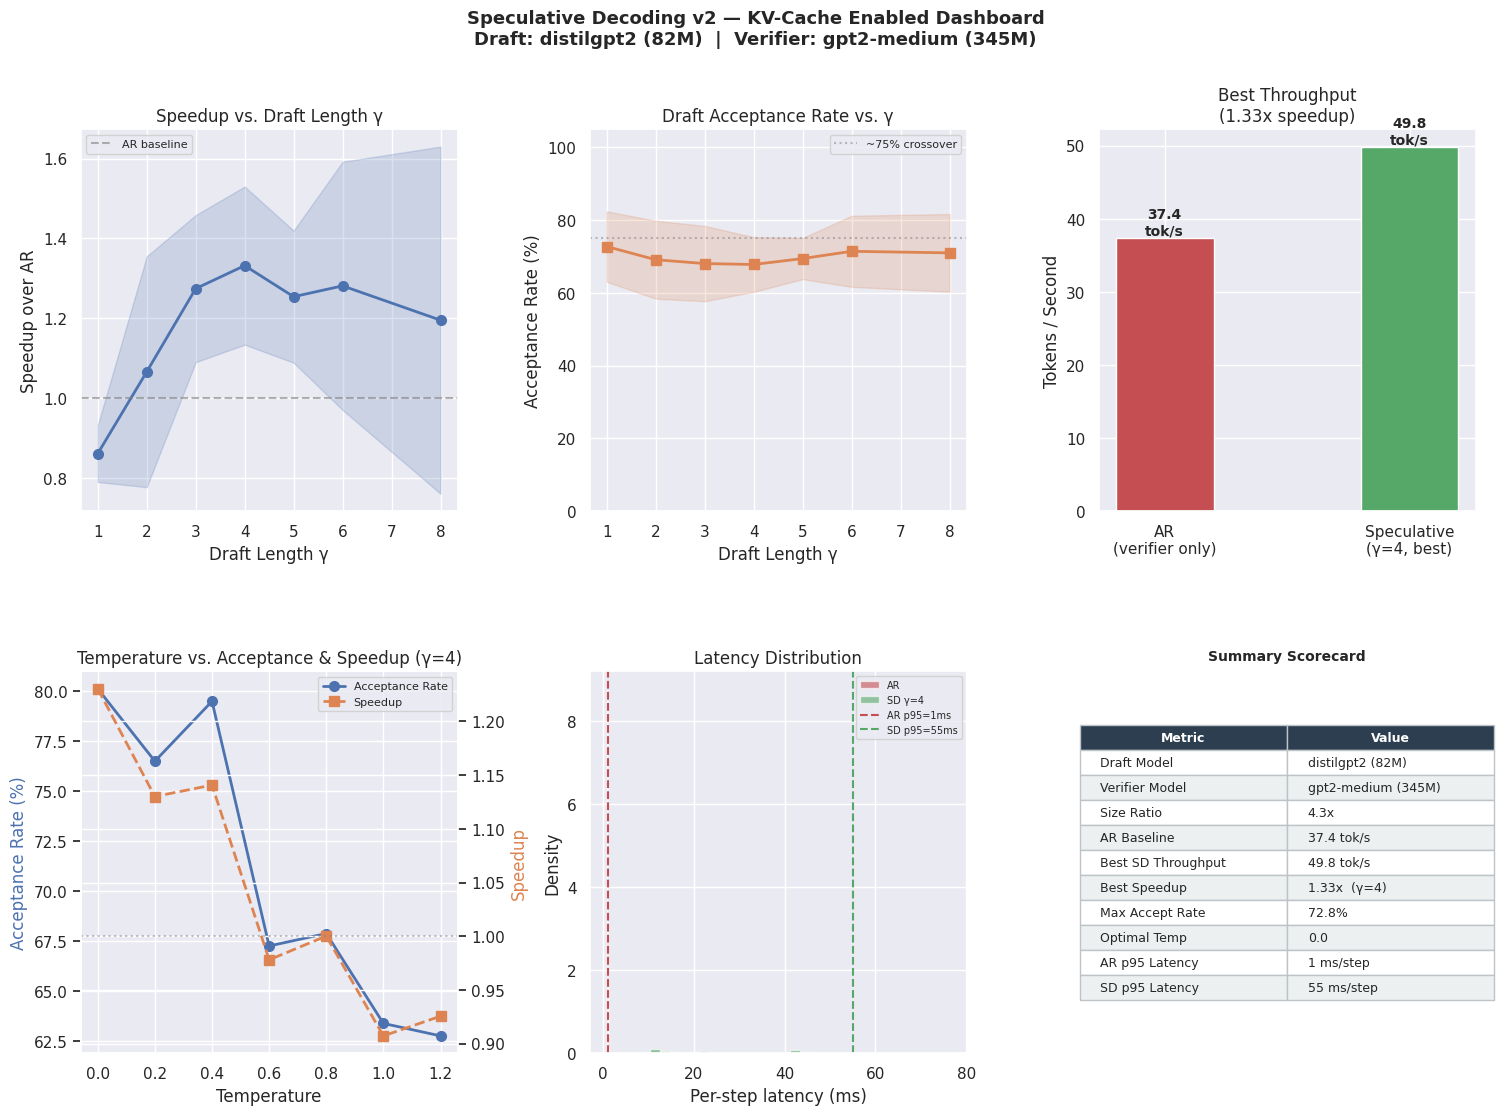

Dashboard saved.


In [19]:
sns.set_theme(style='darkgrid')
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle('Speculative Decoding v2 — KV-Cache Enabled Dashboard\n'
             f'Draft: distilgpt2 (82M)  |  Verifier: gpt2-medium (345M)',
             fontsize=13, fontweight='bold')

BLUE, ORANGE, GREEN, RED = '#4C72B0', '#DD8452', '#55A868', '#C44E52'

# 1. Speedup vs gamma
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df_gamma['gamma'], df_gamma['speedup'], 'o-', color=BLUE, lw=2, ms=7)
ax1.fill_between(df_gamma['gamma'],
    df_gamma['speedup'] - df_gamma['tps_std']/ar_baseline,
    df_gamma['speedup'] + df_gamma['tps_std']/ar_baseline,
    alpha=0.2, color=BLUE)
ax1.axhline(1.0, color='gray', linestyle='--', alpha=0.6, label='AR baseline')
ax1.set_xlabel('Draft Length γ')
ax1.set_ylabel('Speedup over AR')
ax1.set_title('Speedup vs. Draft Length γ')
ax1.legend(fontsize=8)

# 2. Acceptance rate vs gamma
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_gamma['gamma'], df_gamma['acceptance_rate']*100, 's-', color=ORANGE, lw=2, ms=7)
ax2.fill_between(df_gamma['gamma'],
    (df_gamma['acceptance_rate']-df_gamma['accept_std'])*100,
    (df_gamma['acceptance_rate']+df_gamma['accept_std'])*100,
    alpha=0.2, color=ORANGE)
ax2.set_xlabel('Draft Length γ')
ax2.set_ylabel('Acceptance Rate (%)')
ax2.set_title('Draft Acceptance Rate vs. γ')
ax2.set_ylim(0, 105)
ax2.axhline(75, color='gray', linestyle=':', alpha=0.5, label='~75% crossover')
ax2.legend(fontsize=8)

# 3. Best throughput comparison
ax3 = fig.add_subplot(gs[0, 2])
best = df_gamma.loc[df_gamma['speedup'].idxmax()]
bars = ax3.bar(
    ['AR\n(verifier only)', f'Speculative\n(γ={best["gamma"]:.0f}, best)'],
    [ar_baseline, best['tokens_per_sec']],
    color=[RED, GREEN], width=0.4
)
for bar, val in zip(bars, [ar_baseline, best['tokens_per_sec']]):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f'{val:.1f}\ntok/s', ha='center', fontsize=10, fontweight='bold')
ax3.set_ylabel('Tokens / Second')
ax3.set_title(f'Best Throughput\n({best["speedup"]:.2f}x speedup)')

# 4. Temperature vs acceptance + speedup
ax4  = fig.add_subplot(gs[1, 0])
ax4b = ax4.twinx()
l1 = ax4.plot(df_temp['temperature'], df_temp['acceptance_rate']*100,
              'o-', color=BLUE, lw=2, ms=7, label='Acceptance Rate')
l2 = ax4b.plot(df_temp['temperature'], df_temp['speedup'],
               's--', color=ORANGE, lw=2, ms=7, label='Speedup')
ax4b.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax4.set_xlabel('Temperature')
ax4.set_ylabel('Acceptance Rate (%)', color=BLUE)
ax4b.set_ylabel('Speedup', color=ORANGE)
ax4.set_title(f'Temperature vs. Acceptance & Speedup (γ={GAMMA_FIXED})')
lines = l1 + l2
ax4.legend(lines, [l.get_label() for l in lines], fontsize=8)

# 5. Latency distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(ar_arr, bins=30, alpha=0.6, color=RED,   label='AR',     density=True)
ax5.hist(sd_arr, bins=30, alpha=0.6, color=GREEN, label=f'SD γ={GAMMA_FIXED}', density=True)
ax5.axvline(np.percentile(ar_arr, 95), color=RED,   linestyle='--',
            label=f'AR p95={np.percentile(ar_arr,95):.0f}ms')
ax5.axvline(np.percentile(sd_arr, 95), color=GREEN, linestyle='--',
            label=f'SD p95={np.percentile(sd_arr,95):.0f}ms')
ax5.set_xlabel('Per-step latency (ms)')
ax5.set_ylabel('Density')
ax5.set_title('Latency Distribution')
ax5.legend(fontsize=7)

# 6. Summary scorecard
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
best_g   = df_gamma.loc[df_gamma['speedup'].idxmax()]
best_t   = df_temp.loc[df_temp['speedup'].idxmax()]
table_data = [
    ['Draft Model',        'distilgpt2 (82M)'],
    ['Verifier Model',     'gpt2-medium (345M)'],
    ['Size Ratio',         f'{v_params/d_params:.1f}x'],
    ['AR Baseline',        f'{ar_baseline:.1f} tok/s'],
    ['Best SD Throughput', f'{best_g["tokens_per_sec"]:.1f} tok/s'],
    ['Best Speedup',       f'{best_g["speedup"]:.2f}x  (γ={best_g["gamma"]:.0f})'],
    ['Max Accept Rate',    f'{df_gamma["acceptance_rate"].max():.1%}'],
    ['Optimal Temp',       f'{best_t["temperature"]}'],
    ['AR p95 Latency',     f'{np.percentile(ar_arr,95):.0f} ms/step'],
    ['SD p95 Latency',     f'{np.percentile(sd_arr,95):.0f} ms/step'],
]
tbl = ax6.table(cellText=table_data, colLabels=['Metric', 'Value'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECF0F1')
    cell.set_edgecolor('#BDC3C7')
ax6.set_title('Summary Scorecard', fontsize=10, fontweight='bold', pad=8)

plt.savefig('spec_decoding_v2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved.')

## 10. Save Results

In [20]:
df_gamma.to_csv('spec_v2_gamma_sweep.csv', index=False)
df_temp.to_csv('spec_v2_temp_sweep.csv',   index=False)
print('Results saved:')
print('   spec_v2_gamma_sweep.csv')
print('   spec_v2_temp_sweep.csv')
print('   spec_decoding_v2_dashboard.png')
print(f'\nKey findings:')
best = df_gamma.loc[df_gamma['speedup'].idxmax()]
print(f'  AR baseline      : {ar_baseline:.1f} tok/s')
print(f'  Best speedup     : {best["speedup"]:.2f}x at γ={best["gamma"]:.0f}')
print(f'  Best throughput  : {best["tokens_per_sec"]:.1f} tok/s')
print(f'  Max accept rate  : {df_gamma["acceptance_rate"].max():.1%}')
print(f'  Best temperature : {df_temp.loc[df_temp["speedup"].idxmax(), "temperature"]}')

Results saved:
   spec_v2_gamma_sweep.csv
   spec_v2_temp_sweep.csv
   spec_decoding_v2_dashboard.png

Key findings:
  AR baseline      : 37.4 tok/s
  Best speedup     : 1.33x at γ=4
  Best throughput  : 49.8 tok/s
  Max accept rate  : 72.8%
  Best temperature : 0.0
